# Stardist 2D Cell Nuclei Segmentation

This notebook demonstrates 3D cell nuclei segmentation using StarDist, a deep learning model for instance segmentation of star-convex objects. It covers loading a 3D microscopy volume with BioIO, normalizing the data, running StarDist inference to generate instance masks, and visualizing the results overlaid on the raw volume in Napari.

## Learning Outcomes

By the end of this notebook, you will be able to:

1. **Load and inspect a 3D microscopy volume** using BioIO and Dask for memory-aware access.
2. **Normalize and prepare 3D data** for StarDist inference, including axis handling and scaling.
3. **Run a pretrained StarDist 3D model** to obtain instance masks for nuclei.
4. **Evaluate segmentations in Napari** by overlaying label masks on the raw volume and adjusting visualization settings.

## Load the resampled Lund data

We will use [BioIO](https://bioio-devs.github.io/bioio/OVERVIEW.html) to read the 3D `lund1051_resampled.tif` volume. BioIO exposes a Dask-backed array so we can defer loading until needed for visualization or model inference.

In [1]:
#import torch

#if torch.cuda.is_available():
#    print("Pytorch: ✅ GPU activa:", torch.cuda.get_device_name(0))
#else:
#    print("Pytorch: ❌ No se detecta GPU, usando CPU")


import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("Tensorflow: ✅ GPU activa:", gpus)
else:
    print("Tensorflow: ❌ No se detecta GPU, usando CPU")
    

Tensorflow: ❌ No se detecta GPU, usando CPU


In [1]:
from bioio import BioImage
#image_handle = BioImage("../data/IXMtest_E19_s2_w1752F162C-2C91-4A67-BF4F-D073C3D88291.tif")
#image_data = image_handle.dask_data.squeeze()

image_handle = BioImage("../data/Tissue_16x_avg.nd2")
#image_data = image_handle.dask_data.squeeze()
#image_data = image_handle.dask_data.squeeze()[0]
image_data = image_handle.dask_data.squeeze()[1]

#image_handle = BioImage("../data/Nuclei_avg16x.nd2")
#image_data = image_handle.dask_data.squeeze()


image_data = image_handle.dask_data.squeeze()[1]
image_data = image_data.rechunk('auto')
image_data

dask.array<getitem, shape=(2048, 2048), dtype=uint16, chunksize=(2048, 2048), chunktype=numpy.ndarray>

## Visualize the volume in Napari

Napari provides interactive 3D navigation. Rendering the Dask array keeps memory usage manageable until tiles are requested.

In [4]:
import napari

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image_data, name="Lund resampled", rendering="attenuated_mip")
napari.run()

## Prepare and run StarDist 3D

StarDist models predict object centers and star-convex polygons/surfaces. We will use a pretrained 3D model and normalize the volume intensities before inference.

In [2]:
from stardist.models import StarDist2D
from csbdeep.utils import normalize

#model = StarDist2D.from_pretrained("2D_demo")

model = StarDist2D(config=None, name="2D_demo", basedir="../models")

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.486166, nms_thresh=0.5.


In [3]:
help(model.predict_instances)

Help on method _predict_instances_generator in module stardist.models.base:

_predict_instances_generator(img, axes=None, normalizer=None, sparse=True, prob_thresh=None, nms_thresh=None, scale=None, n_tiles=None, show_tile_progress=True, verbose=False, return_labels=True, predict_kwargs=None, nms_kwargs=None, overlap_label=None, return_predict=False) method of stardist.models.model2d.StarDist2D instance
    Predict instance segmentation from input image.
    
    Parameters
    ----------
    img : :class:`numpy.ndarray`
        Input image
    axes : str or None
        Axes of the input ``img``.
        ``None`` denotes that axes of img are the same as denoted in the config.
    normalizer : :class:`csbdeep.data.Normalizer` or None
        (Optional) normalization of input image before prediction.
        Note that the default (``None``) assumes ``img`` to be already normalized.
    sparse: bool
        If true, aggregate probabilities/distances sparsely during tiled
        predicti

In [4]:
# Materializar el array
volume = image_data.compute()

# Asegurarte de que sea 2D (Y,X)
img2d = volume.squeeze()

# Normalizar con percentiles típicos
img2d_norm = normalize(img2d, 1, 99)

# Predicción indicando los ejes correctos
labels, details = model.predict_instances(
    img2d_norm,
    axes="YX",   # correcto para imágenes 2D
    prob_thresh=0.1,
    nms_thresh=0.1,
)


In [5]:
labels

array([[   0,    0,    0, ..., 3299, 3299, 3299],
       [   0,    0,    0, ..., 3299, 3299, 3299],
       [   0,    0,    0, ..., 3299, 3299, 3299],
       ...,
       [   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0]],
      shape=(2048, 2048), dtype=int32)

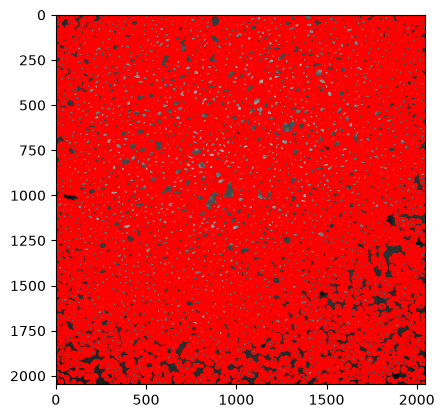

In [6]:
import matplotlib.pyplot as plt
plt.imshow(img2d_norm, cmap="gray")
plt.contour(labels, colors="r")
plt.show()

## Inspect StarDist results in Napari

Overlay labels on the raw data and adjust opacity/colormap to spot under- or over-segmentation.

In [7]:
import napari
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(volume, name="Lund resampled (norm)", rendering="attenuated_mip")
viewer.add_labels(labels, name="StarDist nuclei", opacity=0.5)
napari.run()

## Practice questions

1. How does changing the normalization percentiles affect small, dim nuclei?
2. Which visualization settings (gamma, colormap, opacity) help you spot missed nuclei?
3. If you see merged objects, which StarDist parameters would you adjust first (e.g., `prob_thresh`, `nms_thresh`)?
4. What happens when you switch to a model fine-tuned on your own annotations?

## Useful Resources

- [Stardist Napari plugin](https://github.com/stardist/stardist-napari)
- [Stardist Notebook Examples](https://github.com/stardist/stardist/tree/main/examples)
- [Notebook fro big images](https://github.com/stardist/stardist/blob/main/examples/other2D/predict_big_data.ipynb)